# Worksheet Runthrough

## Solving ODE: Euler, Midpoint and Curve Fitting (Worksheet 4)

$$\frac{dy}{dt} = p   $$
$$ \frac{dp}{dt} = - 4 \pi^2 y           $$

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [6]:
def f(t,y):
    return np.asarray([y[1],-4*(np.pi**2)*y[0]])

def euler(f, x, y, h):
    return y + h * f(x, y)

def midpoint(f, x, y, h):
    k1 = h * f(x, y)
    return y + (h * f(x + h / 2, y + k1 / 2))

def call(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)))
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys

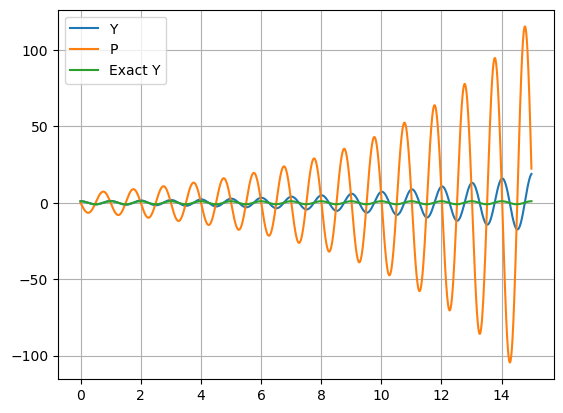

In [7]:
h= 1.0e-2
t0=0
tf=15
y_ini = np.asarray([1.0,0.0])
xs = np.arange(t0,tf,h)
N=len(xs)

y_euler = call(euler, f, y_ini, N, xs, h)
y_midpoint = call(midpoint, f, y_ini, N, xs, h)
y_exact = np.cos(2*np.pi*xs)


plt.plot(xs, y_euler[:,0],label="Y")
plt.plot(xs, y_euler[:,1], label="P")
plt.plot(xs, y_exact, label="Exact Y")
plt.grid()
plt.legend()

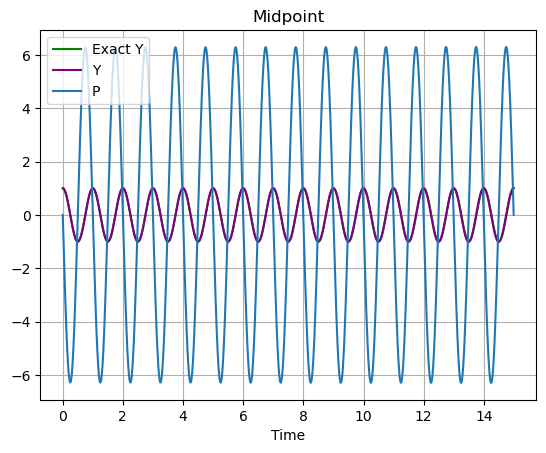

In [8]:
plt.plot(xs,y_exact, label = "Exact Y", color="green")
plt.plot(xs, y_midpoint[:, 0], label="Y",color="purple")
plt.plot(xs, y_midpoint[:, 1], label="P")
plt.xlabel("Time")
plt.title("Midpoint")
plt.legend()
plt.grid()

0.000100 	 1.993531e-02 	 1.939629e-09
0.000158 	 3.177917e-02 	 4.955842e-09
0.000251 	 5.083276e-02 	 1.888804e-08
0.000398 	 8.175359e-02 	 9.853774e-08
0.000631 	 1.326336e-01 	 4.314014e-07
0.001000 	 2.182164e-01 	 1.862729e-06
0.001585 	 3.673236e-01 	 2.805848e-06
0.002512 	 6.419774e-01 	 1.074454e-05
0.003981 	 1.193659e+00 	 8.285954e-05
0.006310 	 2.470012e+00 	 2.844245e-04
0.010000 	 6.146543e+00 	 1.095993e-03


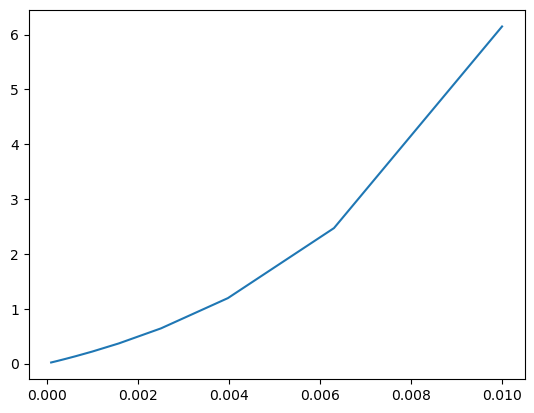

In [9]:
hn = 10.0**(np.arange(-4.0, -2.0+0.2, 0.2))

errors_euler=np.zeros(len(hn))
errors_midpoint=np.zeros(len(hn))
for i,h in enumerate(hn):
    xs = np.arange(t0,10.0+h, h)
    N= len(xs)
    y_exact = np.cos(2*np.pi*xs)
    y_euler = call(euler, f, y_ini, N, xs, h)
    y_midpoint = call(midpoint, f, y_ini, N, xs, h)
    errors_euler[i] = abs(y_euler[-1,0] - y_exact[-1])
    errors_midpoint[i] = abs(y_midpoint[-1,0] - y_exact[-1])

hn_list = []
err_euler_list = []
err_midpoint_list = []

for i, h in enumerate(hn):
    hn_list.append(h)
    err_euler_list.append(errors_euler[i])
    err_midpoint_list.append(errors_midpoint[i])

plt.plot(hn_list, err_euler_list)   
for i in range(len(hn)): 
    print("%.6f \t %.6e \t %.6e" % (hn_list[i], err_euler_list[i], err_midpoint_list[i]))
#string formatting

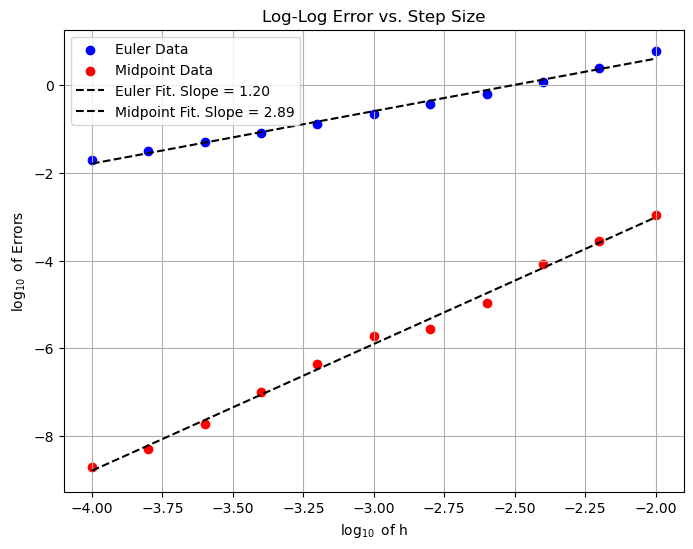

In [10]:
xd = np.log10(hn)
yd_euler = np.log10(errors_euler)
yd_midpoint = np.log10(errors_midpoint)

# Define the fitting function
def line(x, m, c):
    return x*m + c

# Fit the data
popt_euler, _  = curve_fit(line, xd, yd_euler, p0=[1.0, 1.0])
popt_midpoint, _  = curve_fit(line, xd, yd_midpoint, p0=[1.0, 1.0])

# Generate smooth fit
xfine = np.linspace(xd[0], xd[-1], 1000)
yfine_euler = line(xfine, *popt_euler)
yfine_midpoint = line(xfine, *popt_midpoint)

# Plot the data and the fit
plt.figure(figsize=(8, 6))
plt.scatter(xd, yd_euler, color = "blue", label="Euler Data")
plt.scatter(xd, yd_midpoint, color = "red", label="Midpoint Data")
plt.plot(xfine, yfine_euler, label=f"Euler Fit. Slope = {popt_euler[0]:.2f}", color="k", ls = "--")
plt.plot(xfine, yfine_midpoint, label=f"Midpoint Fit. Slope = {popt_midpoint[0]:.2f}", color="k", ls = "--")
plt.xlabel(r"$\log_{10}$ of h")
plt.ylabel(r"$\log_{10}$ of Errors")
plt.grid()
plt.legend()
plt.title("Log-Log Error vs. Step Size")
plt.show()

## Solving ODEs: Verlet, Velocity Verlet and RK4 (Worksheet 5)

$$\frac{dy}{dt} = p   $$
$$ \frac{dp}{dt} = - 4 \pi^2 y $$

In [15]:
def verlet(f1, x, yn, ynm1, h):
    return 2*yn - ynm1 + f1(x, yn)*(h**2)


def velocity_verlet(f1, x, yn, vn, h):
    ynp1 = yn + vn*h + 0.5*f1(x, yn)*(h**2)
    vnp1 = vn + 0.5*(f1(x, yn) + f1(x + h, ynp1))*h
    return ynp1, vnp1

def rk4(f1, x, y, h):
    k1 = h * f1(x, y)
    k2 = h * f1(x + h / 2, y + k1 / 2)
    k3 = h * f1(x + h / 2, y + k2 / 2)
    k4 = h * f1(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6


def caller_y(method, fn, y0, v0, N, xs, h):
    ys = np.zeros(N)
    
    ys[0] = y0
    
    t0 = xs[0]
    
    # Often this is given.
    ys[1] = y0 + v0*h + 0.5*fn(t0, y0)*(h**2)

    # Loop starts 
    for i in range(2, N):
        x = xs[i]
        ys[i] = method(fn, x, ys[i-1], ys[i-2], h)
    
    return ys


def caller_yv(method, fn, y0, v0, N, xs, h):
    
    ys = np.zeros(N)
    vs = np.zeros(N)
    
    ys[0] = y0
    vs[0] = v0

    
    for i in range(1, N):
        x = xs[i]
        ys[i], vs[i] = method(fn, x, ys[i-1], vs[i-1], h)
    
    return ys, vs

def caller_rk4(method, fn, y_ini, N, xs, h):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = method(fn, x, y, h)
    return ys



In [17]:
def f(t,y):
    return np.asarray([y[1], -4*(np.pi**2)*y[0]])

def g(w,z):
    return -4*(np.pi**2)*z

h = 1.0e-2
t0 = 0.0
tf=15.0
y_ini=np.asarray([1.0,0.0])
y0=y_ini[0]
v0 = y_ini[1]
xs=np.arange(t0,tf,h)
N=len(xs)

ysV = caller_y(verlet, g, y0, v0, N, xs, h)


ysVV, vsVV = caller_yv(velocity_verlet, g, y0, v0, N, xs, h)


ysrk4=caller_rk4(rk4, f, y_ini,N,xs,h)
y_exact = np.cos(2*np.pi*xs)


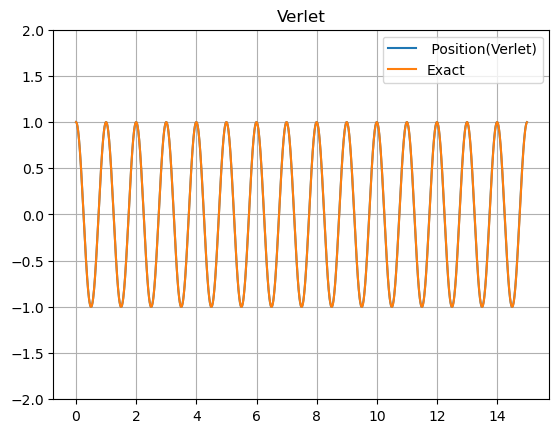

In [18]:
plt.plot(xs, ysV, label=" Position(Verlet)")
plt.plot(xs, y_exact, label="Exact")
plt.ylim(-2.0,2.0)
plt.title("Verlet")
plt.grid()
plt.legend()

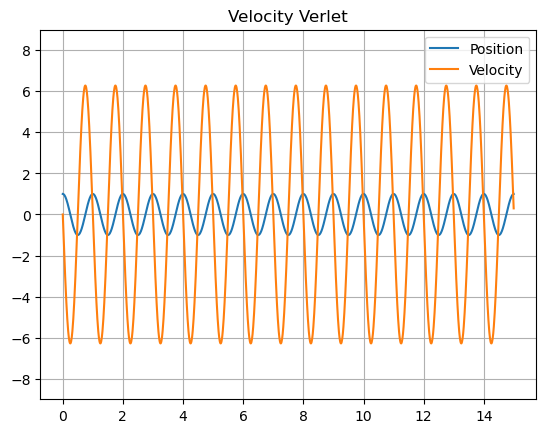

In [20]:
plt.plot(xs,ysVV, label="Position")
plt.plot(xs,vsVV, label = "Velocity")
plt.ylim(-9.0,9.0)
plt.title("Velocity Verlet")
plt.legend()
plt.grid()

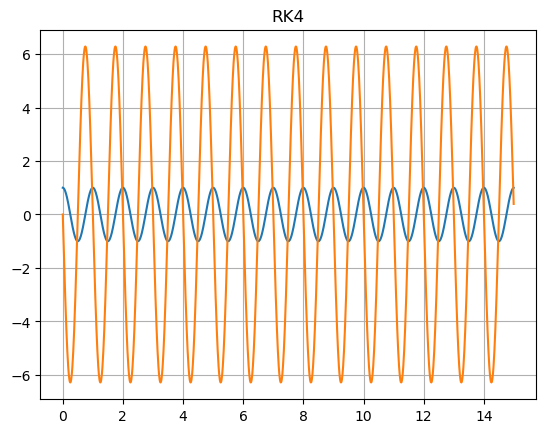

In [21]:
plt.plot(xs, ysrk4)
plt.title("RK4")
plt.grid()

In [22]:
hn = 10.0**(np.arange(-4.0, -2.0+0.2, 0.2))

errors_verlet = np.zeros(len(hn))
errors_vverlet = np.zeros(len(hn))
errors_rk4 = np.zeros(len(hn))

for i,h in enumerate(hn):
    N= int(round((tf-t0)/h))
    h = (tf - t0)/N
    xs = t0 + np.arange(N+1)*h      # consistent time array
    
    y_exact_final = np.cos(2*np.pi*tf)

    ys_v = caller_y(verlet, g, y0, v0, N, xs, h)
    ys_vv, vs_vv = caller_yv(velocity_verlet, g, y0, v0, N, xs, h)
    ys_rk4=caller_rk4(rk4, f, y_ini,N,xs,h)

    errors_verlet[i] = abs(ys_v[-1] - y_exact_final)
    errors_vverlet[i] = abs(ys_vv[-1] - y_exact_final)
    errors_rk4[i] = abs(ys_rk4[-1,0] - y_exact_final)

In [23]:
hn_list = []
err_verlet_list = []
err_vverlet_list = []
err_rk4_list= []

for i, h in enumerate(hn):
    hn_list.append(h)
    err_verlet_list.append(errors_verlet[i])
    err_vverlet_list.append(errors_vverlet[i])
    err_rk4_list.append(errors_rk4[i])
    
for i in range(len(hn)): 
    print("%.6f \t %.6e \t %.6e \t %.6e" % (hn_list[i], err_verlet_list[i], err_vverlet_list[i],err_rk4_list[i]))
#string formatting

0.000100 	 1.964306e-07 	 1.964192e-07 	 1.973921e-07
0.000158 	 4.919464e-07 	 4.919520e-07 	 4.958223e-07
0.000251 	 1.230072e-06 	 1.230073e-06 	 1.245463e-06
0.000398 	 3.067342e-06 	 3.067342e-06 	 3.128502e-06
0.000631 	 7.615796e-06 	 7.615796e-06 	 7.858575e-06
0.001000 	 1.877714e-05 	 1.877714e-05 	 1.973916e-05
0.001585 	 4.578389e-05 	 4.578390e-05 	 4.958616e-05
0.002512 	 1.095727e-04 	 1.095727e-04 	 1.245284e-04
0.003981 	 2.543825e-04 	 2.543825e-04 	 3.128149e-04
0.006310 	 5.603264e-04 	 5.603264e-04 	 7.860947e-04
0.010000 	 1.119958e-03 	 1.119958e-03 	 1.974678e-03


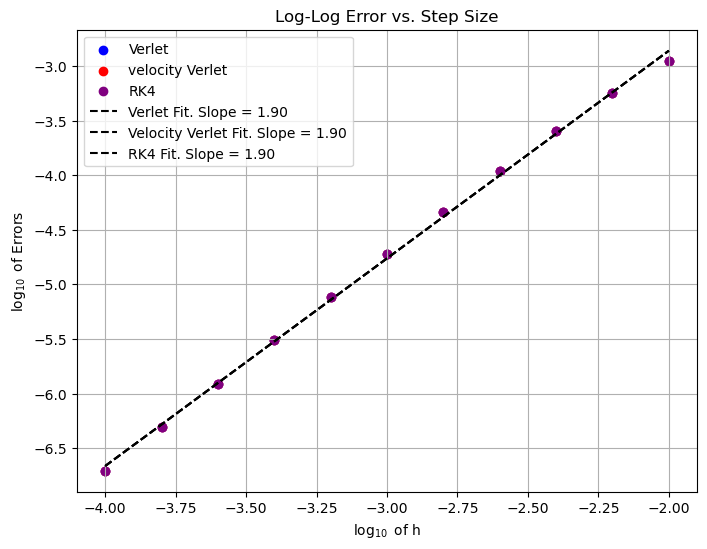

In [24]:
#(c)


# Error data in log-log format
xd = np.log10(hn)
yd_v = np.log10(errors_verlet)
yd_vv = np.log10(errors_vverlet)
yd_rk4= np.log10(errors_vverlet)

# Define the fitting function
def line(x, m, c):
    return x*m + c

# Curve fitting
popt_v, _  = curve_fit(line, xd, yd_v ,p0=[1.0, 1.0])
popt_vv, _  = curve_fit(line, xd, yd_vv, p0=[1.0, 1.0])
popt_rk4, _ = curve_fit(line, xd, yd_rk4, p0=[1.0,0.0])


xfine = np.linspace(xd[0], xd[-1], 1000)
yfine_v = line(xfine, *popt_v)
yfine_vv = line(xfine, *popt_vv)
yfine_rk4 = line(xfine, *popt_rk4)

plt.figure(figsize=(8, 6))
plt.scatter(xd, yd_v, color = "blue", label="Verlet")
plt.scatter(xd, yd_vv, color = "red", label="velocity Verlet")
plt.scatter(xd, yd_rk4, color = "purple", label="RK4")
plt.plot(xfine, yfine_v, label=f"Verlet Fit. Slope = {popt_v[0]:.2f}", color="k", ls = "--")
plt.plot(xfine, yfine_vv, label=f"Velocity Verlet Fit. Slope = {popt_vv[0]:.2f}", color="k", ls = "--")
plt.plot(xfine, yfine_rk4, label=f"RK4 Fit. Slope = {popt_rk4[0]:.2f}", color="k", ls = "--")

plt.xlabel(r"$\log_{10}$ of h")
plt.ylabel(r"$\log_{10}$ of Errors")
plt.grid()
plt.legend()
plt.title("Log-Log Error vs. Step Size")
plt.show()

# $\frac{dx}{dt} = v_x$
 # $\frac{dy}{dt} = v_y$
 # $\frac{dv_x}{dt} = - \frac{\gamma}{m} v_x$
# $\frac{dv_y}{dt} = - g - \frac{\gamma}{m} v_y$

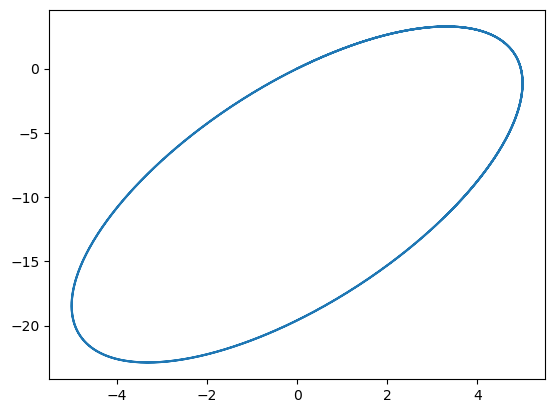

In [35]:
grav = -9.8
gamma = 2
mass = 2

def fx(t, X): 
    x, vx = X
    return np.array([vx,-vx*gamma/mass])

def fy(t, Y): #derivative function
    y,vy = Y
    return np.array([vy, grav - vy*gamma/mass])

def accx(t, vx):
    return - vx*gamma/mass

def accy(t,vy):
    return grav - vy*gamma/mass

def verlet(f1, x, yn, ynm1, h):
    return 2*yn - ynm1 + f1(x, yn)*(h**2)


def velocity_verlet(f1, x, yn, vn, h):
    ynp1 = yn + vn*h + 0.5*f1(x, yn)*(h**2)
    vnp1 = vn + 0.5*(f1(x, yn) + f1(x + h, ynp1))*h
    return ynp1, vnp1


def caller_yv(method, fn, y0, v0, N, xs, h):
    ys = np.zeros(N)
    
    ys[0] = y0
    
    t0 = xs[0]
    
    # Often this is given.
    ys[1] = y0 + v0*h + 0.5*fn(t0, y0)*(h**2)

    # Loop starts 
    for i in range(2, N):
        x = xs[i]
        ys[i] = method(fn, x, ys[i-1], ys[i-2], h)
    
    return ys


def caller_yvv(method, fn, y0, v0, N, xs, h):
    
    ys = np.zeros(N)
    vs = np.zeros(N)
    
    ys[0] = y0
    vs[0] = v0

    
    for i in range(1, N):
        x = xs[i]
        ys[i], vs[i] = method(fn, x, ys[i-1], vs[i-1], h)
    
    return ys, vs

h = 1.0e-2
t0 = 0.0
tf=15.0
x0 = 0
y0 = 0
vx0 = 5.0
vy0 = 5.0*np.sqrt(3)


xs=np.arange(t0,tf,h)
N=len(xs)
#x_ini = np.asarray([0.0,5.0])

xsV = caller_yv(verlet, accx, x0, vx0, N, xs, h)
xsVV, vxVV = caller_yvv(velocity_verlet, accx, x0, vx0, N, xs, h)
ysV = caller_yv(verlet, accy, y0, vy0, N, xs, h)


plt.plot(xsV, ysV)


## Adaptive Time-Stepping: Dormand Prince (Worksheet 6)

### Van der Pol Oscillator
 #### $$\frac{d^2 y}{dx^2} = \mu (1-y^2)\frac{dy}{dx} - \lambda y$$


In [29]:
# Dormand-Prince in matrix form
a = [0.2, 0.3, 0.8, 8/9, 1.0, 1.0]
b = [
    [1/5, 0, 0, 0, 0, 0],
    [3/40, 9/40, 0, 0, 0, 0],
    [44/45, -56/15, 32/9, 0, 0, 0],
    [19372/6561, -25360/2187, 64448/6561, -212/729, 0, 0],
    [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, 0],
    [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84]
]
c = [35/384, 0, 500/1113, 125/192, -2187/6784, 11/84, 0]

# Dormand-Prince
a2 = 1/5;  b21 = 1/5;
a3 = 3/10; b31 = 3/40;       b32 = 9/40;
a4 = 4/5;  b41 = 44/45;      b42 = -56/15;      b43 = 32/9;
a5 = 8/9;  b51 = 19372/6561; b52 = -25360/2187; b53 = 64448/6561; b54 =-212/729;
a6 = 1;    b61 = 9017/3168;  b62 = -355/33;     b63 = 46732/5247; b64 = 49/176;  b65 = -5103/18656;
a7 = 1;    b71 = 35/384;     b72 = 0;           b73 = 500/1113;   b74 = 125/192; b75 = -2187/6784;  b76 = 11/84;

c1 = 35/384; c2 = 0; c3 = 500/1113; c4 = 125/192; c5=-2187/6784; c6 = 11/84; c7 = 0;
c1s = 5179/57600; c2s = 0; c3s = 7571/16695; c4s = 393/640; c5s = -92097/339200; c6s = 187/2100; c7s = 1/40;

In [30]:
def func(t, Y):
    y1, y2 = Y
    dy1 = y2  #dy1/dx = y2
    dy2 = mu * (1 - y1**2) * y2 - lam * y1  #d^2y1/dx^2 = dy2/dx = mu(1-y1^2)y2 - lambda*y1 (two variable equation)
    return np.array([dy1, dy2])
mu = 5.0
lam = 40.0

# Embedded Runge-Kutta formulas
def erk54(f, x, y, h):
    k1 = h*f(x, y)
    k2 = h*f(x + a2*h, y + b21*k1)
    k3 = h*f(x + a3*h, y + b31*k1 + b32*k2)
    k4 = h*f(x + a4*h, y + b41*k1 + b42*k2 + b43*k3)
    k5 = h*f(x + a5*h, y + b51*k1 + b52*k2 + b53*k3 + b54*k4)
    k6 = h*f(x + a6*h, y + b61*k1 + b62*k2 + b63*k3 + b64*k4 + b65*k5)
    y5 = y + c1*k1 + c2*k2 + c3*k3 + c4*k4 + c5*k5 + c6*k6       
    k7 = h*f(x + a7*h, y5)
    y4 = y + c1s*k1 + c2s*k2 + c3s*k3 + c4s*k4 + c5s*k5 + c6s*k6 + c7s*k7
    return y5, y4

# A caller function
def caller5(my_method, fn, y_ini, x0, xT, h):
    # x values uniformly sampled
    xs = np.arange(x0, xT, h)
    # number of points
    N = len(xs)
    # Initialize
    y = np.asarray(y_ini)
    # Initialize storage
    ys = np.zeros((N, len(y_ini)))
    # Loop over all xs
    for i in range(N):
        # store and ...
        ys[i,:] = y
        x = xs[i]
        # ... update
        y, y4 = my_method(fn,x,y,h)
    return ys


def caller4(my_method, fn, y_ini, x0, xT, h):
    # x values uniformly sampled
    xs = np.arange(x0, xT, h)
    # number of points
    N = len(xs)
    # Initialize
    y = np.asarray(y_ini)
    # Initialize storage
    ys = np.zeros((N, len(y_ini)))
    # Loop over all xs
    for i in range(N):
        # store and ...
        ys[i,:] = y
        x = xs[i]
        # ... update
        y5, y = my_method(fn,x,y,h)
    return ys

In [31]:


# Initialize the parameters
max_iter = 500
abstol = 1.0e-6   #absolute tolerance
reltol = 1.0e-8   #relative tolerance
y_ini = [0.5,0.0]
x0 = 0.0
xT = 20.0
h = 1.0e-4       #starting time step
xs = np.arange(x0, xT, h)

# Caller functions provide the solutions
yserk5 = caller5(erk54, func, y_ini, x0, xT, h)
yserk4 = caller4(erk54, func, y_ini, x0, xT, h)

In [32]:
# Initialize parameters
max_iter = 20000
abstol = 1.0e-6
reltol = 1.0e-8
y_ini = [0.5,0.0]
x0 = 0.0
xT = 20.0
h0 = 1.0e-4

# Final call 
xs54, yserk54 = caller54(func, y_ini, x0, xT, h0, max_iter, abstol, reltol)  #
#Stored time steps, and list of canonical variables


NameError: name 'caller54' is not defined

In [ ]:
xs54l = [xs54[i][0] for i in range(len(xs54))]
plt.plot(np.diff(xs54l),'bo',markersize=2)
plt.xlabel('Serial number')
plt.ylabel('h values')
plt.xticks([i for i in range(20)])
plt.grid()